**Problem Statement:**
Google Play Store team is about to launch a new feature wherein, certain apps that are promising are boosted in visibility. The boost will
manifest in multiple ways including higher priority in recommendations sections (“Similar apps”, “You might also like”, “New and updated
games”). These will also get a boost in search results visibility. This feature will help bring more attention to newer apps that have the
potential.


**Analysis to be done:**
The problem is to identify the apps that are going to be good for Google to promote. App ratings, which are provided by the customers,
are always great indicators of the goodness of the app. The problem reduces to: predict which apps will have high ratings.

**Data Dictionary:**

Variables Description

- App: Application name

- Category: Category to which the app belongs

- Rating: Overall user rating of the app

- Reviews: Number of user reviews for the app

- Size: Size of the app

- Installs: Number of user downloads/installs for the app

- Type: Paid or Free

- Price: Price of the app

- Content: Rating Age group the app is targeted at - Children / Mature 21+ / Adult

- Genres: An app can belong to multiple genres (apart from its main category). For example, a musical family game will belong to Music, Game, Family genres

- Last: Updated Date when the app was last updated on Play Store

- Current Ver: Current version of the app available on Play Store

- Android Ver: Minimum required Android version

#### Log Safety Function:

In [1]:
def safe_log1p(X):
    X = np.where(np.isfinite(X), X, 0)  # replace inf/nan with 0
    X = np.clip(X, 0, None)
    return np.log1p(X)

#### 1) Importing Necessary Libraries:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, date

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV,  ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import TransformerMixin, BaseEstimator

#### 2) Importing Data:

In [3]:
df = pd.read_csv('googleplaystore.csv')

In [4]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,"June 20, 2018",1.1,4.4 and up


In [5]:
df.shape

(10841, 13)

#### 3) Data Cleaning:

In [6]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [7]:
df.dtypes

App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content_Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

- Columns like Reviews, Size, Installs, Price should be numeric but are stored as Object type.

##### 1) Handling Wrong Data Types and Cleaning Data:

In [8]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,"June 20, 2018",1.1,4.4 and up


###### 1) Dropping Unnecesaary Columns:

- App: Name of the application is not a feature and is unique for all records, should be deleted.
- Current Ver: Current Version of the Application, not useful in analysis, should Be dropped.
- Android Ver: Required Android Version, not necessary for model building.

In [9]:
df.drop(['App','Current Ver', 'Android Ver'], axis= 1, inplace= True)

In [10]:
df.head()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Last Updated
0,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,"January 7, 2018"
1,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,"January 15, 2018"
2,ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,"August 1, 2018"
3,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,"June 8, 2018"
4,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,"June 20, 2018"


###### 2) Transforming Date and Android Version Columns:

In [11]:
df['Days Since Update'] = (pd.to_datetime(date.today()) - pd.to_datetime(df['Last Updated'], errors= 'coerce')).dt.days

In [12]:
df.drop('Last Updated', axis= 1, inplace= True)

In [13]:
df.head()

,Category,Rating,Reviews,Size,Installs,Type,Price,Content_Rating,Genres,Days Since Update
0,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art_&_Design,2855.0
1,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art_&_Design_Pretend_Play,2847.0
2,ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art_&_Design,2649.0
3,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art_&_Design,2703.0
4,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art_&_Design_Creativity,2691.0


###### 3) Category:

In [14]:
df['Category'].value_counts()

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                       1
Name: count, dtype: int64

In [15]:
len(df['Category'].unique())

34

- Category has a moderately high Cardinality with 34 categories.
- We can use One Hot Encoding here.
- Note: Different methods should be considered is Cardinality increases.

In [16]:
# Preprocessing Transformer:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category'])
])

###### 4) Rating:

- Rating is Out Target Variable, so no need to do any Preprocessing ot Transformation.

In [17]:
df['Rating'].isna().sum()

np.int64(1474)

- Rating has 1474 Missing Values.
- As Rating is Target Variable, we shouldn't Impute Missing Values.
- Two Ways here are:
    - Drop Records with Rating Value Missing.
    - Separate Records with Missing Rating into different Dataframe, to be used as Test Data after Model Building.
- For now, we are dropping Records with Missing Rating Value.

In [18]:
df = df.dropna(subset= ['Rating']).reset_index(drop= True)

###### 5) Reviews:

In [19]:
df['Reviews']

0          159
1          967
2        87510
3       215644
4          967
         ...  
9362         7
9363        38
9364         4
9365       114
9366    398307
Name: Reviews, Length: 9367, dtype: object

In [20]:
# df['Reviews'].astype('int')

- Looks like some of the values in Reviews has 'M' or 'k' attached to them for Millions or Thousands, that's why the Column Data Type is Object.

In [21]:
def parse_review(value):
    """
    Takes in a Single Value at time to process and clean.
    """

    value = str(value).strip()
        
    try:
        if value.endswith('B'):
            return float(value[:-1]) * 1000000000
        elif value.endswith('M'):
            return float(value[:-1]) * 1000000
        elif value.endswith('k'):
            return float(value[:-1]) * 1000
        else:
            return float(value)
    except:
        return np.nan

In [22]:
def clean_reviews(X):
    """
    Applies parse_review to each cell.
    """
    if isinstance(X, pd.DataFrame):
        # If a DataFrame is passed (n_samples, 1)
        return X.iloc[:, 0].apply(parse_review).to_frame()
    elif isinstance(X, pd.Series):
        return X.apply(parse_review)
    else:
        # In case it's a numpy array
        return pd.Series(X).apply(parse_review)

In [23]:
review_cleaner = FunctionTransformer(clean_reviews)

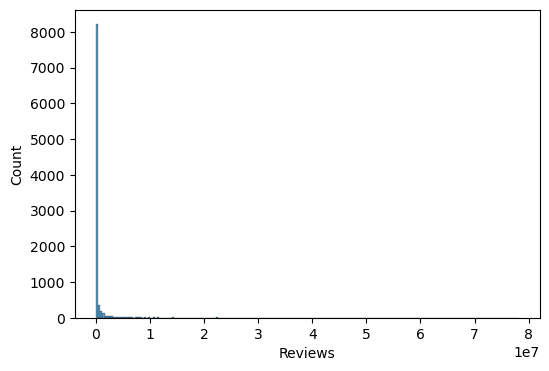

In [24]:
# Checking Distribution of Reviews:

plt.figure(figsize= (6,4))
sns.histplot(clean_reviews(df['Reviews']))
plt.show()

- We will need to Apply Log Transformation here to make the Distribution Normal.

In [25]:
# Pipleline for Preprocessing Steps on Reviews:

review_pipeline = Pipeline([
    ('clean', review_cleaner),
    ('transform', FunctionTransformer(safe_log1p, validate= False)),
    ('scaler', StandardScaler())
])

In [26]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews'])
])

###### 6) Size:

In [27]:
df['Size']

0                      19M
1                      14M
2                     8.7M
3                      25M
4                     2.8M
               ...        
9362                  2.6M
9363                   53M
9364                  3.6M
9365    Varies with device
9366                   19M
Name: Size, Length: 9367, dtype: object

In [28]:
df['Size'].value_counts()

Size
Varies with device    1637
14M                    166
12M                    161
11M                    160
15M                    159
                      ... 
383k                     1
454k                     1
812k                     1
442k                     1
619k                     1
Name: count, Length: 415, dtype: int64

- We will replace 'M', 'k' here with 1000000 and 1000.
- We will replace Varies with device to NaN.

In [29]:
def parse_size(value):
    """
    Takes in a Single Value at time to process and clean.
    """

    value = str(value).strip()

    if value.lower() == 'varies with device':
        return np.nan

    try:
        if value.endswith('G'):
            return float(value[:-1]) * 1000000000
        elif value.endswith('M'):
            return float(value[:-1]) * 1000000
        elif value.endswith('k'):
            return float(value[:-1]) * 1000
        else:
            return float(value)
    except:
        return np.nan

In [30]:
def clean_size(X):
    """
    Applies parse_review to each cell.
    """
    if isinstance(X, pd.DataFrame):
        # If a DataFrame is passed (n_samples, 1)
        return X.iloc[:, 0].apply(parse_size).to_frame()
    elif isinstance(X, pd.Series):
        return X.apply(parse_size)
    else:
        # In case it's a numpy array
        return pd.Series(X).apply(parse_size)

In [31]:
size_cleaner = FunctionTransformer(clean_size)

- We will also have to deal with NaN values that above Transformation creates inplace of 'Varies with Device' values.
- We will fill in those missing values with Category wise Median size for each app.

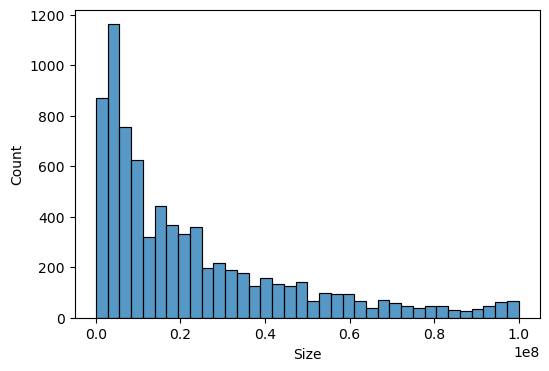

In [32]:
plt.figure(figsize= (6,4))
sns.histplot(clean_reviews(df['Size']))
plt.show()

- Now, Size column has multiple preprocessing Steps to follow:
    - Data Cleaning (Replacing 'M','k','Varies with Device').
    - Missing Value Imputation.
    - Cube Root Transformation.
- We will create a Pipeline of preprocessing steps for Size and then integrate it with main Column Transformer.

In [33]:
size_pipeline = Pipeline([
    ('Cleaning', size_cleaner),
    ('imputer', SimpleImputer(strategy= 'median')),
    ('transform', FunctionTransformer(np.cbrt)),
    ('scaler', StandardScaler())
])

In [34]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews']),
    ('Size', size_pipeline, ['Category', 'Size'])
])

###### 7) Installs:

In [35]:
df['Installs']

0           10,000+
1          500,000+
2        5,000,000+
3       50,000,000+
4          100,000+
           ...     
9362           500+
9363         5,000+
9364           100+
9365         1,000+
9366    10,000,000+
Name: Installs, Length: 9367, dtype: object

In [36]:
df['Installs'].value_counts()

Installs
1,000,000+        1577
10,000,000+       1252
100,000+          1150
10,000+           1010
5,000,000+         752
1,000+             713
500,000+           538
50,000+            467
5,000+             432
100,000,000+       409
100+               309
50,000,000+        289
500+               201
500,000,000+        72
10+                 69
1,000,000,000+      58
50+                 56
5+                   9
1+                   3
Free                 1
Name: count, dtype: int64

- Value in Isntalls have invalid characters like '+' or ',' in it.
- One value is 'Free'.

In [37]:
def parse_install(value):

    value = str(value).strip()

    if value.lower() in ['free', 'nan', 'none']:
        return np.nan

    cleaned_value = value.replace('+','').replace(',','')

    try:
        return int(cleaned_value)
    except:
        return np.nan

In [38]:
def clean_installs(X):
    """
    Applies parse_review to each cell.
    """
    if isinstance(X, pd.DataFrame):
        # If a DataFrame is passed (n_samples, 1)
        return X.iloc[:, 0].apply(parse_install).to_frame()
    elif isinstance(X, pd.Series):
        return X.apply(parse_install)
    else:
        # In case it's a numpy array
        return pd.Series(X).apply(parse_install)

In [39]:
installs_cleaner = FunctionTransformer(clean_installs)

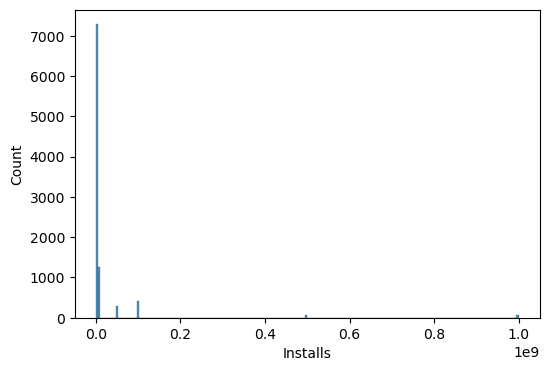

In [40]:
plt.figure(figsize= (6,4))
sns.histplot(clean_installs(df['Installs']))
plt.show()

- We will also have to take care of Missing Values we created by above step (replacing 'free' with NaN).
- We will also have to scale the Installs feature.
- Log Transformation.

In [41]:
installs_pipeline = Pipeline([
    ('clean', installs_cleaner),
    ('impute', SimpleImputer(strategy= 'median')),
    ('transform', FunctionTransformer(safe_log1p, validate= False)),
    ('scaler', StandardScaler())
])

In [42]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews']),
    ('Size', size_pipeline, ['Category', 'Size']),
    ('Installs', installs_pipeline, ['Installs'])
])

###### 8) Type:

In [43]:
df['Type']

0       Free
1       Free
2       Free
3       Free
4       Free
        ... 
9362    Free
9363    Free
9364    Free
9365    Free
9366    Free
Name: Type, Length: 9367, dtype: object

In [44]:
df['Type'].value_counts()

Type
Free    8719
Paid     647
0          1
Name: count, dtype: int64

In [45]:
 def parse_type(value):

    value = str(value).strip().capitalize()

    if value not in ['Free', 'Paid']:
        return np.nan
    return value

In [46]:
def clean_type(X):
    """
    Applies parse_review to each cell.
    """
    if isinstance(X, pd.DataFrame):
        # If a DataFrame is passed (n_samples, 1)
        return X.iloc[:, 0].apply(parse_type).to_frame()
    elif isinstance(X, pd.Series):
        return X.apply(parse_type)
    else:
        # In case it's a numpy array
        return pd.Series(X).apply(parse_type)

In [47]:
type_cleaner = FunctionTransformer(clean_type)

- We will have to take care of missing values that above steps generate.
- Preprocessing Steps for Type:
    - Cleaning
    - Missing Value Handling
    - One Hot Encoding.

In [48]:
type_pipeline = Pipeline([
    ('cleaner', type_cleaner),
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [49]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews']),
    ('Size', size_pipeline, ['Category', 'Size']),
    ('Installs', installs_pipeline, ['Installs']),
    ('Type', type_pipeline, ['Type'])
])

###### 9) Price:

In [50]:
df['Price']

0       0
1       0
2       0
3       0
4       0
       ..
9362    0
9363    0
9364    0
9365    0
9366    0
Name: Price, Length: 9367, dtype: object

In [51]:
df['Price'].value_counts()

Price
0          8719
$2.99       114
$0.99       107
$4.99        70
$1.99        59
           ... 
$299.99       1
$379.99       1
$37.99        1
$18.99        1
$1.20         1
Name: count, Length: 74, dtype: int64

- In Price, we have '$' symbol attached to some values, which we will have to remove.

In [52]:
def parse_price(value):

    value = str(value).strip()

    if value.lower() in ['free', '0', '0.0']:
        return 0.0

    try:
        return float(value.replace('$',''))
    except:
        return np.nan

In [53]:
def clean_price(X):
    """
    Applies parse_price to each cell.
    """
    if isinstance(X, pd.DataFrame):
        # If a DataFrame is passed (n_samples, 1)
        return X.iloc[:, 0].apply(parse_price).to_frame()
    elif isinstance(X, pd.Series):
        return X.apply(parse_price)
    else:
        # In case it's a numpy array
        return pd.Series(X).apply(parse_price)

In [54]:
price_cleaner = FunctionTransformer(clean_price)

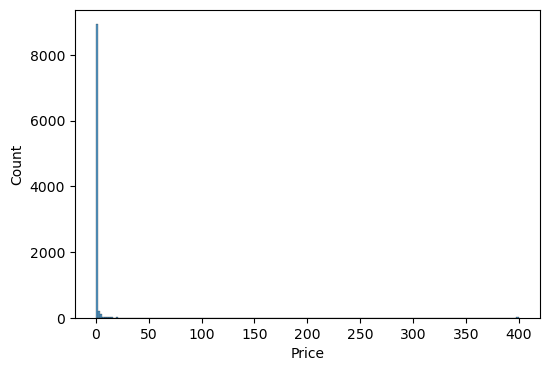

In [55]:
plt.figure(figsize= (6,4))
sns.histplot(clean_price(df['Price']))
plt.show()

- We will also have to take care of Missing Values we created while cleaning function.
- Log Transformation.

In [56]:
price_pipeline = Pipeline([
    ('cleaner', price_cleaner),
    ('imputer', SimpleImputer(strategy= 'constant', fill_value= 0.0)),
    ('transform', FunctionTransformer(safe_log1p, validate= False)),
    ('scaler', StandardScaler())
])

In [57]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews']),
    ('Size', size_pipeline, ['Category', 'Size']),
    ('Installs', installs_pipeline, ['Installs']),
    ('Type', type_pipeline, ['Type']),
    ('Price', price_pipeline, ['Price'])
])

###### 10) Contebt Rating:

In [58]:
df['Content_Rating']

0         Everyone
1         Everyone
2         Everyone
3             Teen
4         Everyone
           ...    
9362      Everyone
9363      Everyone
9364      Everyone
9365    Mature_17+
9366      Everyone
Name: Content_Rating, Length: 9367, dtype: object

In [59]:
df['Content_Rating'].value_counts()

Content_Rating
Everyone           7420
Teen               1084
Mature_17+          461
Everyone_10+        397
Adults_only_18+       3
Unrated               1
Name: count, dtype: int64

In [60]:
df['Content_Rating'].isna().sum()

np.int64(1)

- Just One Missing Value, to be filled with Mode.
- One Hot Encoding.

In [61]:
content_rating_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [62]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews']),
    ('Size', size_pipeline, ['Category', 'Size']),
    ('Installs', installs_pipeline, ['Installs']),
    ('Type', type_pipeline, ['Type']),
    ('Price', price_pipeline, ['Price']),
    ('Content_Rating', content_rating_pipeline, ['Content_Rating'])
])

###### 11) Genres:

In [63]:
df['Genres']

0                    Art_&_Design
1       Art_&_Design_Pretend_Play
2                    Art_&_Design
3                    Art_&_Design
4         Art_&_Design_Creativity
                  ...            
9362                    Education
9363                    Education
9364                    Education
9365            Books_&_Reference
9366                    Lifestyle
Name: Genres, Length: 9367, dtype: object

In [64]:
df['Genres'].value_counts()

Genres
Tools                          733
Entertainment                  533
Education                      468
Action                         358
Productivity                   351
                              ... 
Health_&_Fitness_Education       1
Music_&_Audio_Music_&_Video      1
Arcade_Pretend_Play              1
Entertainment_Education          1
Strategy_Creativity              1
Name: count, Length: 116, dtype: int64

In [65]:
df['Genres'].isna().sum()

np.int64(0)

- We have too many different categories for genres here to One Hot Encode (It would create 115 columns).
- We will take first genre metiones as prime genre for each app and use that to One hot encode.

In [66]:
def parse_genre(value):

    value = value.replace('_&_','_').replace('&','').replace('__','_')

    main_genre = value.split('_')[0].strip().title()

    return main_genre

In [67]:
def clean_genres(X):
    """
    Applies parse_genre to each cell.
    """
    if isinstance(X, pd.DataFrame):
        # If a DataFrame is passed (n_samples, 1)
        return X.iloc[:, 0].apply(parse_genre).to_frame()
    elif isinstance(X, pd.Series):
        return X.apply(parse_genre)
    else:
        # In case it's a numpy array
        return pd.Series(X).apply(parse_genre)

In [68]:
genre_cleaner = FunctionTransformer(clean_genres)

- We will also have to take care of Missing Values Created by above step.
- One Hot Encoding.

In [69]:
genres_pipeline = Pipeline([
    ('cleaner', genre_cleaner),
    ('imputer', SimpleImputer(strategy= 'constant', fill_value= 'Unknown')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

In [70]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews']),
    ('Size', size_pipeline, ['Category', 'Size']),
    ('Installs', installs_pipeline, ['Installs']),
    ('Type', type_pipeline, ['Type']),
    ('Price', price_pipeline, ['Price']),
    ('Content_Rating', content_rating_pipeline, ['Content_Rating']),
    ('Genres', genres_pipeline, ['Genres'])
])

###### 12) Days Since Update:

In [71]:
df['Days Since Update']

0       2855.0
1       2847.0
2       2649.0
3       2703.0
4       2691.0
         ...  
9362    3058.0
9363    3021.0
9364    2675.0
9365    3939.0
9366    2656.0
Name: Days Since Update, Length: 9367, dtype: float64

In [72]:
df['Days Since Update'].isna().sum()

np.int64(1)

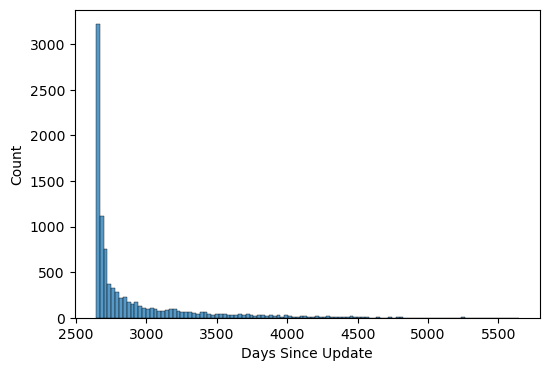

In [73]:
plt.figure(figsize= (6,4))
sns.histplot(df['Days Since Update'])
plt.show()

- Has skewed distribution, but transformations are not working, keeping it as it is.
- Handling Missing Value.
- Scaling.

In [74]:
days_since_updated_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', StandardScaler())
])

In [75]:
# Updating Preprocessor:

preprocessor = ColumnTransformer([
    ('Category', OneHotEncoder(handle_unknown= 'ignore'), ['Category']),
    ('Reviews', review_pipeline, ['Reviews']),
    ('Size', size_pipeline, ['Category', 'Size']),
    ('Installs', installs_pipeline, ['Installs']),
    ('Type', type_pipeline, ['Type']),
    ('Price', price_pipeline, ['Price']),
    ('Content_Rating', content_rating_pipeline, ['Content_Rating']),
    ('Genres', genres_pipeline, ['Genres']),
    ('Days_Since_Updated', days_since_updated_pipeline, ['Days Since Update'])
])

#### 4) Train Test Split:

In [76]:
# Separating Features and Target:

X = df.drop('Rating', axis= 1)
y = df['Rating']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [78]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7493, 9)
(1874, 9)
(7493,)
(1874,)


#### 5) Model Building and Evaluation:

In [79]:
models = {
    'Linear Regression': LinearRegression(),
    'RidgeCV': RidgeCV(alphas = (0.01, 0.1, 1, 5, 10, 25, 50, 100),
                        cv= 10,
                        scoring= 'r2'),
    'LassoCV': LassoCV(cv= 10, random_state= 42, max_iter= 10000),
    'ElasticNetCV': ElasticNetCV(l1_ratio= [0.001, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1], 
                            eps= 0.001, cv= 10, max_iter= 1000000)
}

In [80]:
results = {}

for name, model in models.items():

    pipe = Pipeline([
        ('Preprocessing', preprocessor),
        ('Model', model)
    ])

    pipe.fit(X_train, y_train) # Model Fitting

    y_pred = pipe.predict(X_test) # Predictions Using Model

    MAE = mean_absolute_error(y_test, y_pred)
    RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
    R2_Score = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': MAE,
        'RMSE': RMSE,
        'R2-Score': R2_Score
    }

In [81]:
results = pd.DataFrame(results).T.sort_values(by= 'R2-Score', ascending= False)
results

,MAE,RMSE,R2-Score
ElasticNetCV,0.323239,0.459642,0.143068
RidgeCV,0.323294,0.459717,0.142787
LassoCV,0.323313,0.459723,0.142767
Linear Regression,0.323786,0.460227,0.140884


The models achieved an average R² of 0.14, meaning approximately 14% of the variation in app ratings can be explained by the available features.
The mean absolute error (MAE) of ~0.32 indicates that the predicted ratings are typically within ±0.3 points of the actual ratings — a reasonable margin given the narrow rating scale (1–5).

These results suggest that:

- The current features (like installs, size, category, price, etc.) have limited predictive power for app ratings.

- Ratings are likely influenced by qualitative factors such as app design, performance, user experience, and marketing reputation, which are not captured in this dataset.

- Therefore, linear models reach a performance ceiling here — further improvements would require:

- More expressive features (e.g., text analysis of app descriptions, sentiment from user reviews),
Or more advanced models (tree-based or ensemble methods) capable of capturing non-linear relationships.